# CNN

### Import Library

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import tensorflow as tf
import pandas as pd
import seaborn as sns

from PIL import Image
from tensorflow.keras.models import (
    Sequential, 
    load_model
)
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    AveragePooling2D,
    Flatten,
    Dense
)
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

### Utility Functions

In [78]:
CLASS_NAMES = [
    "buildings",
    "forest",
    "glacier",
    "mountain",
    "sea",
    "street"
]

In [79]:
def load_image(image_path, target_size=(150,150)):

    image = Image.open(image_path)

    image = image.convert("RGB")

    image = image.resize(target_size)

    image_array = np.array(image)

    image_array = image_array / 255.0

    return image_array

In [80]:
def batch_loader(image_paths):

    images = []

    for path in image_paths:

        image = load_image(path)

        images.append(image)

    images = np.array(images)

    return images

In [81]:
def load_balanced_dataset(
    dataset_dir,
    sample_fraction=1.0
):

    print("Menganalisis dataset...")

    categories = sorted(os.listdir(dataset_dir))

    all_paths = {
        cat: [] for cat in categories
    }

    for cat in categories:

        cat_dir = os.path.join(dataset_dir, cat)

        if os.path.isdir(cat_dir):

            for img_name in os.listdir(cat_dir):

                image_path = os.path.join(
                    cat_dir,
                    img_name
                )

                all_paths[cat].append(image_path)

    sampled_counts = [
        int(len(paths) * sample_fraction)
        for paths in all_paths.values()
    ]

    balanced_target = min(sampled_counts)

    print(
        f"Setiap class mengambil "
        f"{balanced_target} gambar"
    )

    X_paths = []
    y_labels = []

    for label_idx, cat in enumerate(categories):

        sampled_paths = random.sample(
            all_paths[cat],
            balanced_target
        )

        X_paths.extend(sampled_paths)

        y_labels.extend(
            [label_idx] * balanced_target
        )

    print("Loading images...")

    X = batch_loader(X_paths)

    y = np.array(y_labels)

    return X, y, categories

### Training Model

In [82]:
train_path = "data/Intel-Image-Classification/seg_train/seg_train"

X_train, y_train, class_names = load_balanced_dataset(
    train_path,
    sample_fraction=1.0
)

print("\nTrain shape:", X_train.shape)
print("Label shape:", y_train.shape)

print("\nClass names:")
print(class_names)

Menganalisis dataset...
Setiap class mengambil 2191 gambar
Loading images...

Train shape: (13146, 150, 150, 3)
Label shape: (13146,)

Class names:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [69]:
test_path = "data/Intel-Image-Classification/seg_test/seg_test"

X_test, y_test, _ = load_balanced_dataset(
    test_path,
    sample_fraction=1.0
)

print("\nTest shape:", X_test.shape)
print("Label shape:", y_test.shape)

Menganalisis dataset...
Setiap class mengambil 437 gambar
Loading images...

Test shape: (2622, 150, 150, 3)
Label shape: (2622,)


In [83]:
def build_cnn_model(
    conv_layers,
    filters,
    kernel_size,
    pooling_type,
    input_shape=(150,150,3),
    num_classes=6
):

    model = Sequential()

    if pooling_type == "max":
        PoolingLayer = MaxPooling2D
    else:
        PoolingLayer = AveragePooling2D

    model.add(
        Conv2D(
            filters=filters[0],
            kernel_size=kernel_size,
            activation='relu',
            input_shape=input_shape
        )
    )

    model.add(
        PoolingLayer(pool_size=(2,2))
    )

    for i in range(1, conv_layers):

        model.add(
            Conv2D(
                filters=filters[i],
                kernel_size=kernel_size,
                activation='relu'
            )
        )

        model.add(
            PoolingLayer(pool_size=(2,2))
        )

    model.add(Flatten())

    model.add(Dense(64, activation='relu'))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [84]:
model = build_cnn_model(
    conv_layers=2,
    filters=[8,16],
    kernel_size=(3,3),
    pooling_type="max"
)

model.summary()

c:\Users\13522\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 148, 148, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 74, 74, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 72, 72, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 36, 36, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,327,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,328,950 (5.07 MB)

 Trainable params: 1,328,950 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [85]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=16
)

Epoch 1/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 99s 101ms/step - accuracy: 0.6238 - loss: 0.9733 - val_accuracy: 0.7216 - val_loss: 0.7482
Epoch 2/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.7703 - loss: 0.6362 - val_accuracy: 0.7685 - val_loss: 0.6518
Epoch 3/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8289 - loss: 0.4888 - val_accuracy: 0.7628 - val_loss: 0.6838
Epoch 4/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8801 - loss: 0.3518 - val_accuracy: 0.7647 - val_loss: 0.7131
Epoch 5/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9166 - loss: 0.2449 - val_accuracy: 0.7597 - val_loss: 0.8028
Epoch 6/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9515 - loss: 0.1546 - val_accuracy: 0.7300 - val_loss: 1.0688
Epoch 7/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9685 - loss: 0.1074 - val_accuracy: 0.7536 - val_loss: 1.0292
Epoch 8/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9761 - loss: 0.0789 -

In [90]:
model.save("cnn_model_v1.keras")

In [91]:
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [92]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   buildings       0.70      0.69      0.69       437
      forest       0.88      0.94      0.91       437
     glacier       0.75      0.58      0.66       437
    mountain       0.76      0.55      0.64       437
         sea       0.54      0.85      0.66       437
      street       0.81      0.71      0.76       437

    accuracy                           0.72      2622
   macro avg       0.74      0.72      0.72      2622
weighted avg       0.74      0.72      0.72      2622



In [93]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[300  20   9   6  51  51]
 [  6 412   1   1   5  12]
 [ 11   3 255  49 115   4]
 [ 15   3  51 242 125   1]
 [ 17   3  23  18 373   3]
 [ 79  27   1   1  17 312]]


Testing 16 variasi Hyperparameter

In [94]:
experiments = []

conv_options = [2, 3]

kernel_options = [
    (3,3),
    (5,5)
]

pooling_options = [
    "max",
    "avg"
]

filter_options = {

    2: [
        [8,16],
        [16,32]
    ],

    3: [
        [8,16,32],
        [16,32,64]
    ]
}

for conv_layers in conv_options:

    for filters in filter_options[conv_layers]:

        for kernel_size in kernel_options:

            for pooling_type in pooling_options:

                experiments.append({
                    "conv_layers": conv_layers,
                    "filters": filters,
                    "kernel_size": kernel_size,
                    "pooling": pooling_type
                })

print("Jumlah eksperimen:", len(experiments))

for i, exp in enumerate(experiments):
    print(f"\nModel {i+1}")
    print(exp)

Jumlah eksperimen: 16

Model 1
{'conv_layers': 2, 'filters': [8, 16], 'kernel_size': (3, 3), 'pooling': 'max'}

Model 2
{'conv_layers': 2, 'filters': [8, 16], 'kernel_size': (3, 3), 'pooling': 'avg'}

Model 3
{'conv_layers': 2, 'filters': [8, 16], 'kernel_size': (5, 5), 'pooling': 'max'}

Model 4
{'conv_layers': 2, 'filters': [8, 16], 'kernel_size': (5, 5), 'pooling': 'avg'}

Model 5
{'conv_layers': 2, 'filters': [16, 32], 'kernel_size': (3, 3), 'pooling': 'max'}

Model 6
{'conv_layers': 2, 'filters': [16, 32], 'kernel_size': (3, 3), 'pooling': 'avg'}

Model 7
{'conv_layers': 2, 'filters': [16, 32], 'kernel_size': (5, 5), 'pooling': 'max'}

Model 8
{'conv_layers': 2, 'filters': [16, 32], 'kernel_size': (5, 5), 'pooling': 'avg'}

Model 9
{'conv_layers': 3, 'filters': [8, 16, 32], 'kernel_size': (3, 3), 'pooling': 'max'}

Model 10
{'conv_layers': 3, 'filters': [8, 16, 32], 'kernel_size': (3, 3), 'pooling': 'avg'}

Model 11
{'conv_layers': 3, 'filters': [8, 16, 32], 'kernel_size': (5, 5),

In [95]:
results = []

for i, exp in enumerate(experiments):

    print(f"TRAINING MODEL {i+1}/16")
    print(exp)

    model = build_cnn_model(
        conv_layers=exp["conv_layers"],
        filters=exp["filters"],
        kernel_size=exp["kernel_size"],
        pooling_type=exp["pooling"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=16,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    model_name = f"cnn_model_{i+1}.keras"

    model.save(model_name)

    results.append({
        "model": i+1,
        "conv_layers": exp["conv_layers"],
        "filters": str(exp["filters"]),
        "kernel_size": str(exp["kernel_size"]),
        "pooling": exp["pooling"],
        "accuracy": test_acc,
        "loss": test_loss
    })

    print("\nSELESAI MODEL", i+1)
    print(f"Accuracy : {test_acc:.4f}")
    print(f"Loss     : {test_loss:.4f}")
    print(f"Saved    : {model_name}")

    tf.keras.backend.clear_session()

    import gc
    gc.collect()


TRAINING MODEL 1/16
{'conv_layers': 2, 'filters': [8, 16], 'kernel_size': (3, 3), 'pooling': 'max'}


c:\Users\13522\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.6321 - loss: 0.9738 - val_accuracy: 0.7323 - val_loss: 0.7497
Epoch 2/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.7556 - loss: 0.6669 - val_accuracy: 0.7731 - val_loss: 0.6543
Epoch 3/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8260 - loss: 0.4865 - val_accuracy: 0.7651 - val_loss: 0.6569
Epoch 4/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8740 - loss: 0.3619 - val_accuracy: 0.7761 - val_loss: 0.6638
Epoch 5/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9184 - loss: 0.2453 - val_accuracy: 0.7777 - val_loss: 0.7272
Epoch 6/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.9503 - loss: 0.1562 - val_accuracy: 0.7784 - val_loss: 0.7808
Epoch 7/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9633 - loss: 0.1232 - val_accuracy: 0.7780 - val_loss: 0.8767
Epoch 8/10
822/822 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9785 - loss: 0.0751 - 

In [96]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="accuracy",
    ascending=False
)

results_df

,model,conv_layers,filters,kernel_size,pooling,accuracy,loss
9,10,3,"[8, 16, 32]","(3, 3)",avg,0.805873,0.670051
13,14,3,"[16, 32, 64]","(3, 3)",avg,0.795957,0.956365
8,9,3,"[8, 16, 32]","(3, 3)",max,0.781465,1.137500
14,15,3,"[16, 32, 64]","(5, 5)",max,0.780320,1.136779
10,11,3,"[8, 16, 32]","(5, 5)",max,0.779558,0.990924
11,12,3,"[8, 16, 32]","(5, 5)",avg,0.773074,0.962134
15,16,3,"[16, 32, 64]","(5, 5)",avg,0.766972,0.977617
4,5,2,"[16, 32]","(3, 3)",max,0.759344,1.321887
5,6,2,"[16, 32]","(3, 3)",avg,0.758581,1.376772
6,7,2,"[16, 32]","(5, 5)",max,0.754005,1.515244


In [97]:
results_df.to_csv(
    "hasil_eksperimen.csv",
    index=False
)

print("File hasil_eksperimen.csv berhasil disimpan")

File hasil_eksperimen.csv berhasil disimpan


In [98]:
best_model = load_model("cnn_model_14.keras")

print("Model terbaik berhasil di-load")

Model terbaik berhasil di-load


In [99]:
y_pred_probs = best_model.predict(X_test)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

print("Prediksi selesai")

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Prediksi selesai


In [100]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   buildings       0.75      0.79      0.77       437
      forest       0.90      0.95      0.93       437
     glacier       0.77      0.73      0.75       437
    mountain       0.77      0.69      0.73       437
         sea       0.77      0.81      0.79       437
      street       0.81      0.80      0.80       437

    accuracy                           0.80      2622
   macro avg       0.79      0.80      0.79      2622
weighted avg       0.79      0.80      0.79      2622



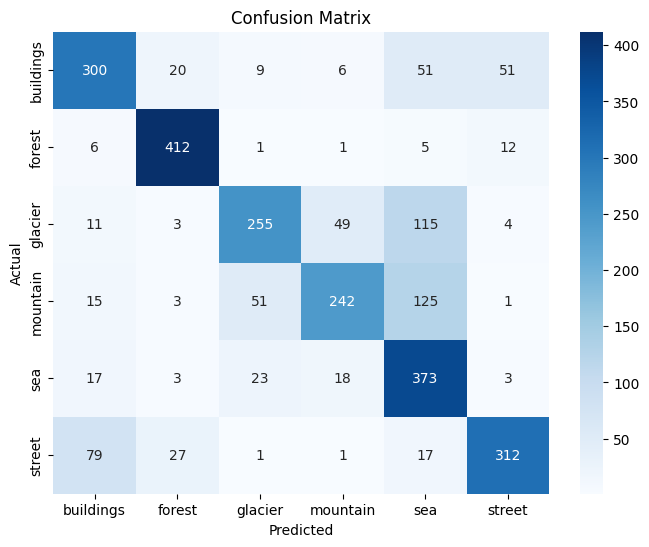

In [101]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [102]:
best_model = load_model("cnn_model_14.keras")

print(best_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 74, 74, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 36, 36, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 17, 17, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,183,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,623,348 (13.82 MB)

 Trainable params: 1,207,782 (4.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,415,566 (9.21 MB)

None


Forward Propagation From Scratch

In [105]:
def relu(x):
    return np.maximum(0, x)

def softmax(x):

    exp_x = np.exp(x - np.max(x))

    return exp_x / np.sum(exp_x)

In [106]:
x = np.array([-2, 0, 3])

print("ReLU:")
print(relu(x))

print("\nSoftmax:")
print(softmax(x))

ReLU:
[0 0 3]

Softmax:
[0.00637746 0.04712342 0.94649912]


In [107]:
conv_weights, conv_bias = best_model.layers[0].get_weights()

print("Kernel shape :", conv_weights.shape)
print("Bias shape   :", conv_bias.shape)

Kernel shape : (3, 3, 3, 16)
Bias shape   : (16,)


In [108]:
def conv2d_forward(input_image, kernels, bias):

    H, W, C = input_image.shape

    kH, kW, C_in, C_out = kernels.shape

    out_H = H - kH + 1
    out_W = W - kW + 1

    output = np.zeros((out_H, out_W, C_out))

    # sliding kernel
    for h in range(out_H):

        for w in range(out_W):

            patch = input_image[
                h:h+kH,
                w:w+kW,
                :
            ]

            for c in range(C_out):

                kernel = kernels[:, :, :, c]

                output[h, w, c] = (
                    np.sum(patch * kernel)
                    + bias[c]
                )

    return output

In [109]:
sample_image = X_test[0]

conv_output = conv2d_forward(
    sample_image,
    conv_weights,
    conv_bias
)

print("Output shape:")
print(conv_output.shape)

Output shape:
(148, 148, 16)


In [110]:
conv_output_relu = relu(conv_output)

print("Output setelah ReLU:")
print(conv_output_relu.shape)

Output setelah ReLU:
(148, 148, 16)


In [111]:
def average_pooling_forward(input_feature_map,
                            pool_size=2,
                            stride=2):

    H, W, C = input_feature_map.shape

    out_H = H // stride
    out_W = W // stride

    output = np.zeros((out_H, out_W, C))

    for h in range(out_H):

        for w in range(out_W):

            h_start = h * stride
            h_end = h_start + pool_size

            w_start = w * stride
            w_end = w_start + pool_size

            patch = input_feature_map[
                h_start:h_end,
                w_start:w_end,
                :
            ]

            output[h, w, :] = np.mean(
                patch,
                axis=(0,1)
            )

    return output

In [113]:
pool_output = average_pooling_forward(
    conv_output_relu
)

print("Output pooling:")
print(pool_output.shape)

Output pooling:
(74, 74, 16)


In [114]:
conv2_weights, conv2_bias = best_model.layers[2].get_weights()

print("Kernel shape :", conv2_weights.shape)
print("Bias shape   :", conv2_bias.shape)

Kernel shape : (3, 3, 16, 32)
Bias shape   : (32,)


In [115]:
conv2_output = conv2d_forward(
    pool_output,
    conv2_weights,
    conv2_bias
)

print("Conv2 output:")
print(conv2_output.shape)

Conv2 output:
(72, 72, 32)


In [116]:
conv2_relu = relu(conv2_output)

print(conv2_relu.shape)

(72, 72, 32)


In [117]:
pool2_output = average_pooling_forward(
    conv2_relu
)

print(pool2_output.shape)

(36, 36, 32)


In [118]:
conv3_weights, conv3_bias = best_model.layers[4].get_weights()

print("Kernel shape :", conv3_weights.shape)
print("Bias shape   :", conv3_bias.shape)

Kernel shape : (3, 3, 32, 64)
Bias shape   : (64,)


In [119]:
conv3_output = conv2d_forward(
    pool2_output,
    conv3_weights,
    conv3_bias
)

print("Conv3 output:")
print(conv3_output.shape)

Conv3 output:
(34, 34, 64)


In [120]:
# RELU KETIGA

conv3_relu = relu(conv3_output)

print(conv3_relu.shape)

(34, 34, 64)


In [121]:
pool3_output = average_pooling_forward(
    conv3_relu
)

print(pool3_output.shape)

(17, 17, 64)


In [122]:
def flatten_forward(input_feature_map):

    return input_feature_map.flatten()

In [123]:
flatten_output = flatten_forward(
    pool3_output
)

print(flatten_output.shape)

(18496,)


In [124]:
dense1_weights, dense1_bias = best_model.layers[7].get_weights()

print("Weight shape :", dense1_weights.shape)
print("Bias shape   :", dense1_bias.shape)

Weight shape : (18496, 64)
Bias shape   : (64,)


In [125]:
def dense_forward(input_vector,
                  weights,
                  bias):

    return np.dot(input_vector, weights) + bias

In [126]:
dense1_output = dense_forward(
    flatten_output,
    dense1_weights,
    dense1_bias
)

print(dense1_output.shape)

(64,)


In [127]:
dense1_relu = relu(dense1_output)

print(dense1_relu.shape)

(64,)


In [128]:
output_weights, output_bias = best_model.layers[8].get_weights()

print("Weight shape :", output_weights.shape)
print("Bias shape   :", output_bias.shape)

Weight shape : (64, 6)
Bias shape   : (6,)


In [129]:
output_logits = dense_forward(
    dense1_relu,
    output_weights,
    output_bias
)

print(output_logits.shape)

(6,)


In [130]:
prediction_probs = softmax(output_logits)

print(prediction_probs)

[1.08134761e-02 9.89155089e-01 8.02692936e-12 6.17925181e-19
 2.44457109e-08 3.14107981e-05]


In [131]:
predicted_class = np.argmax(prediction_probs)

print("Predicted class index:")
print(predicted_class)

print("\nPredicted class name:")
print(class_names[predicted_class])

Predicted class index:
1

Predicted class name:
forest


Perbandingan Keras vs Scratch

In [132]:
keras_prediction = best_model.predict(
    np.expand_dims(sample_image, axis=0)
)

print(keras_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
[[1.0813488e-02 9.8915511e-01 8.0269263e-12 6.1792548e-19 2.4445795e-08
  3.1410695e-05]]


In [133]:
keras_predicted_class = np.argmax(
    keras_prediction
)

print("Keras predicted index:")
print(keras_predicted_class)

print("\nKeras predicted class:")
print(class_names[keras_predicted_class])

Keras predicted index:
1

Keras predicted class:
forest


In [134]:
print("SCRATCH PREDICTION:")
print(class_names[predicted_class])

print("\nKERAS PREDICTION:")
print(class_names[keras_predicted_class])

SCRATCH PREDICTION:
forest

KERAS PREDICTION:
forest
